/tmp/ipykernel_183409/1649486086.py:28: RuntimeWarning: invalid value encountered in divide
  ax.plot(x, y/x/x/x, color=color, lw=0.5)


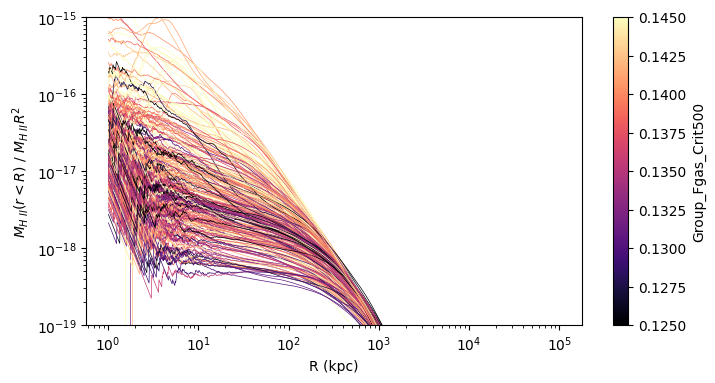

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import h5py

with h5py.File('outputs/tng_cluster_catalog.hdf5', 'r') as f:
    fig, ax = plt.subplots(figsize=(8,4))
    cmap = plt.get_cmap('magma')
    norm = colors.Normalize(vmin=0.125, vmax=0.145)
    # norm = colors.Normalize(vmin=-7, vmax=-5)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

    for i in range(299):
        x = f['table/Group_R_enclosed'][i, :]# / f['table/r500c'][i]
        dx = np.diff(x)
        # print(f['table'].keys())
        # y = f['table/Group_Mion_enclosed'][i, :] / f['table/Group_Mion_enclosed'][i, -1]
        y = f['table/Group_Mion_enclosed'][i, :] / (10**f['table/mhalo_500c'][i]) / f['table/fgas_r500'][i]
        # y = f['table/Group_Mgas_enclosed'][i, :] / f['table/Group_Mgas_enclosed'][i, -1]
        dy = np.diff(y)
        val = f['table/Group_Fgas_Crit500'][i]
        # val = np.log10((y/x/x)[x > 10**2.5][0])
        color = cmap(norm(val))   # ← normalize first!
        # ax.plot(x[1:], dy/dx/x[1:], color=color, lw=0.5)
        ax.plot(x, y/x/x/x, color=color, lw=0.5)
        ax.set_xscale('log')
        ax.set_yscale('log')

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Group_Fgas_Crit500')
    ax.set_xlabel('R (kpc)')
    ax.set_ylabel('$M_{H~II}(r < R)~/~M_{H~II} R^2$')
    # plt.ylim(1e-8, 1e-4)
    # plt.ylim(1e-19, 1e-15)
    # plt.xlim(1, 1e4)


352
352


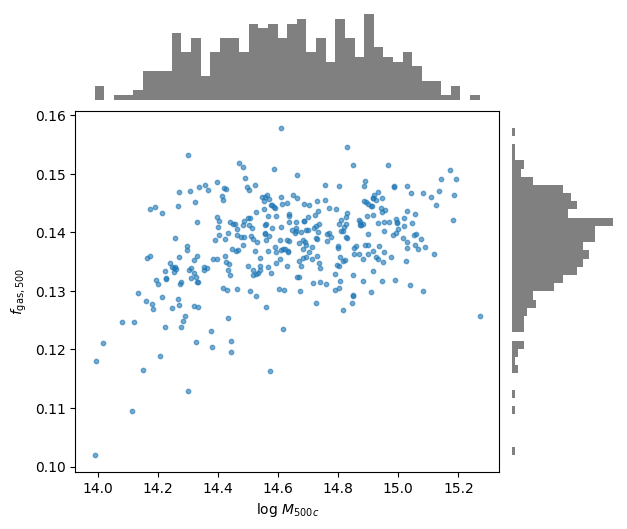

In [8]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec

with h5py.File('outputs/tng_cluster_catalog.hdf5', 'r') as f:
    x = f['table/mhalo_500c'][:]
    y = f['table/fgas_r500'][:]
print(y.size)
# filter out nonpositive x if log scale is used
mask = (x > 0) & (y > 0)
x, y = x[mask], y[mask]
print(y.size)

# --- Layout ---
fig = plt.figure(figsize=(7, 6))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                       wspace=0.05, hspace=0.05)

# Main scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
ax_scatter.scatter(x, y, s=10, alpha=0.6)
ax_scatter.set_xlabel(r'log $M_{500c}$')
ax_scatter.set_ylabel(r'$f_{\mathrm{gas},500}$')

# Top histogram (marginal of x)
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_histx.hist(x, bins=40, color='gray')
ax_histx.axis('off')

# Right histogram (marginal of y)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)
ax_histy.hist(y, bins=40, orientation='horizontal', color='gray')
ax_histy.axis('off')

# optional limits
# ax_scatter.set_xlim(1e14, 1e15)
# ax_scatter.set_ylim(0.03, 0.18)

plt.show()


352
352


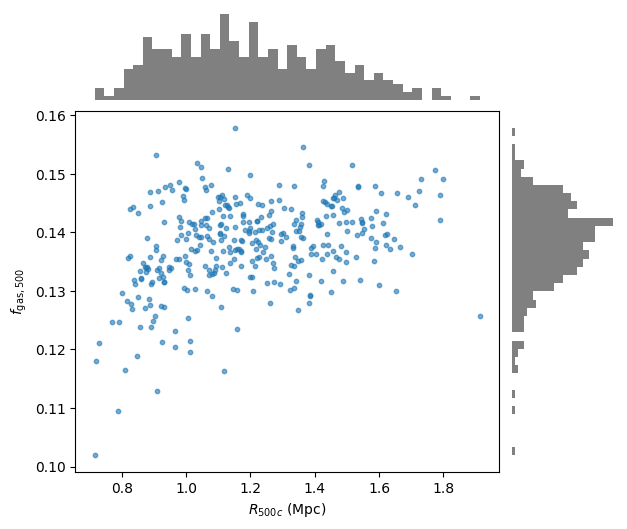

In [4]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec

with h5py.File('outputs/tng_cluster_catalog.hdf5', 'r') as f:
    x = f['table/r500c'][:]
    y = f['table/fgas_r500'][:]
print(y.size)
# filter out nonpositive x if log scale is used
mask = (x > 0) & (y > 0)
x, y = x[mask], y[mask]
print(y.size)

# --- Layout ---
fig = plt.figure(figsize=(7, 6))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                       wspace=0.05, hspace=0.05)

# Main scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
ax_scatter.scatter(x, y, s=10, alpha=0.6)
ax_scatter.set_xlabel(r'$R_{500c}$ (Mpc)')
ax_scatter.set_ylabel(r'$f_{\mathrm{gas},500}$')

# Top histogram (marginal of x)
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_histx.hist(x, bins=40, color='gray')
ax_histx.axis('off')

# Right histogram (marginal of y)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)
ax_histy.hist(y, bins=40, orientation='horizontal', color='gray')
ax_histy.axis('off')

# optional limits
# ax_scatter.set_xlim(1e14, 1e15)
# ax_scatter.set_ylim(0.03, 0.18)

plt.show()
